# PE7023 - Project


Diego de Miranda Gomes

Emuobosa Patience Ojoboh


In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


Reservoir engineers assure you that the inflow can be modeled with the single-phase steady-state solution of the Darcy equation for a vertical fully penetrating well:

![Equation 1](eq1.png)


Plot the productivity index PI as a function of rwf.  Comment on your results.

In [44]:
## Reservoir properties
reservoir_pressure = 3800 # Pressure in psi
reservoir_temperature = 200 # Temperature in °F
k = 40 # Permeability in mD
h = 150 # Thickness in ft
re = 372 # Drainage radius in ft
S = 0 # Skin factor
API = 45 # API gravity
muo = 0.902 # Viscosity in cp
gas_specific_gravity = 0.6636 # Gas specific gravity
GOR = 800 # Gas-oil ratio in scf/STB
Pb = 3800 # Bubble point pressure in psi
Bo = 1.2 # Formation volume factor in bbl/STB

In [45]:
#Load casing data
wellbore_casing = pd.read_csv('datasets/api_casing_table_full_clean.csv')
## Collumn 'Size (in)' has values like '4 1/2', we need to convert them to decimal
wellbore_casing['Size (in) decimal'] = wellbore_casing['Size (in)'].apply(lambda x: eval(x.replace(' ', '+')))
wellbore_casing_external_diameter = wellbore_casing[['Size (in)', 'Size (in) decimal']].copy()
wellbore_casing_external_diameter.drop_duplicates(inplace=True)
max_diameter = 8.5
wellbore_casing_external_diameter = wellbore_casing_external_diameter[wellbore_casing_external_diameter['Size (in) decimal'] <= max_diameter]


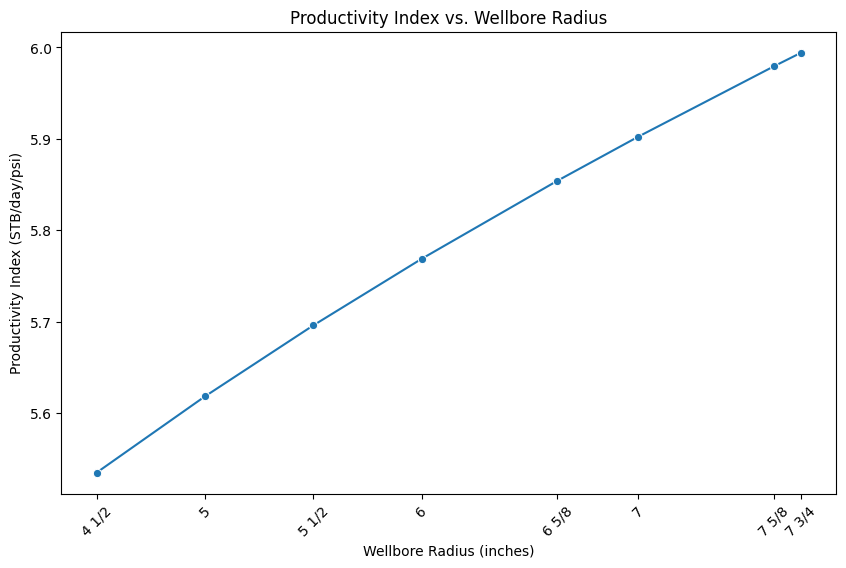

In [51]:
def PI(k, h, Bo, muo, re, rwf, S):
    # Calculate the productivity index (PI) using the given parameters
    # k: permeability (mD)
    # h: thickness of the reservoir (ft)
    # Bo: formation volume factor (bbl/STB)
    # muo: viscosity of oil (cp)
    # re: drainage radius (ft)
    # rwf: wellbore radius (ft)
    # S: skin factor

    # Convert permeability from mD to ft^2
    

    # Calculate the productivity index using the formula:
    # PI = (k * h) / (Bo * muo * (ln(re/rwf) + S))
    PI_value = (k * h) / (141.2 * Bo * muo * (np.log(re / rwf) -0.5 + S))

    return PI_value


## Evaluate different wellbore radii
wellbore_case_inches = wellbore_casing_external_diameter['Size (in) decimal'].values # Wellbore case sizes in inches
wellbore_radii = [case / 2 / 12 for case in wellbore_case_inches] # Convert to feet
PI_values = [PI(k, h, Bo, muo, re, rwf, S) for rwf in wellbore_radii]
# Plotting the results
plt.figure(figsize=(10, 6))
## Use the original 'Size (in)' for the x-axis labels but scale it using the decimal values for the x-axis positions
sns.lineplot(x=wellbore_casing_external_diameter['Size (in) decimal'], y=PI_values, marker='o')
plt.xticks(ticks=wellbore_casing_external_diameter['Size (in) decimal'], labels=wellbore_casing_external_diameter['Size (in)'])
## make x-axis labels inclined
plt.xticks(rotation=45)
plt.title('Productivity Index vs. Wellbore Radius')
plt.xlabel('Wellbore Radius (inches)')
plt.ylabel('Productivity Index (STB/day/psi)')
plt.show()



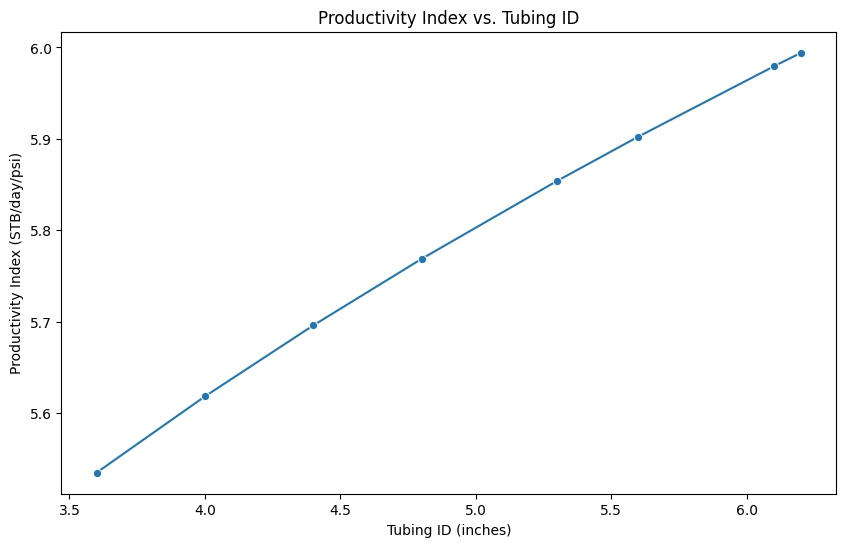

In [52]:
tubing_id = [0.8 * case for case in wellbore_case_inches] # Assuming tubing ID is 80% of the wellbore radius
## Plotiing tubing ID vs. PI
plt.figure(figsize=(10, 6))
sns.lineplot(x=tubing_id, y=PI_values, marker='o')
plt.title('Productivity Index vs. Tubing ID')
plt.xlabel('Tubing ID (inches)')
plt.ylabel('Productivity Index (STB/day/psi)')
plt.show()


In [53]:
#Show Tubing ID vs. PI in a table
data = {'Tubing ID (inches)': tubing_id, 'Productivity Index (STB/day/psi)': PI_values}
df = pd.DataFrame(data)
print(df)


   Tubing ID (inches)  Productivity Index (STB/day/psi)
0                 3.6                          5.534861
1                 4.0                          5.618318
2                 4.4                          5.696012
3                 4.8                          5.768842
4                 5.3                          5.854084
5                 5.6                          5.902546
6                 6.1                          5.979432
7                 6.2                          5.994278
